In [ ]:
!pip install ultralytics
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.5 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define paths for input images and output labels
base_path = "/content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images"
output_labels_path = "/content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/labels"

# Folders to process
folders = ["train", "valid", "test"]
categories = {"Real Human": 0, "Edited Images": 1,"AI human 2":2}

In [ ]:
os.makedirs(output_labels_path, exist_ok=True)

def generate_labels():
    for folder in folders:
        folder_path = os.path.join(base_path, folder)
        label_folder_path = os.path.join(output_labels_path, folder)
        os.makedirs(label_folder_path, exist_ok=True)

        for category, label in categories.items():
            category_path = os.path.join(folder_path, category)

            if os.path.exists(category_path):

                category_label_path = os.path.join(label_folder_path, category)
                os.makedirs(category_label_path, exist_ok=True)

                for filename in os.listdir(category_path):
                    if filename.lower().endswith((".png", ".jpg", ".jpeg",".webp")):

                        label_file_path = os.path.join(
                            category_label_path, os.path.splitext(filename)[0] + ".txt"
                        )


                        with open(label_file_path, "w") as label_file:
                            label_file.write(f"{label}\n")

                        print(f"Label for {filename} written to {label_file_path}")
            else:
                print(f"Category folder does not exist: {category_path}")

generate_labels()

Label for girl-7975892_640.webp written to /content/drive/MyDrive/Deep Fake Images/labels/train/Real Human/girl-7975892_640.txt
Label for fashion-6364998_640.jpg written to /content/drive/MyDrive/Deep Fake Images/labels/train/Real Human/fashion-6364998_640.txt
Label for artist-4622221_640.jpg written to /content/drive/MyDrive/Deep Fake Images/labels/train/Real Human/artist-4622221_640.txt
Label for clouds-1839308_640.jpg written to /content/drive/MyDrive/Deep Fake Images/labels/train/Real Human/clouds-1839308_640.txt
Label for istockphoto-1051228600-612x612.jpg written to /content/drive/MyDrive/Deep Fake Images/labels/train/Real Human/istockphoto-1051228600-612x612.txt
Label for man-4460522_640.jpg written to /content/drive/MyDrive/Deep Fake Images/labels/train/Real Human/man-4460522_640.txt
Label for man-3745031_640.jpg written to /content/drive/MyDrive/Deep Fake Images/labels/train/Real Human/man-3745031_640.txt
Label for fisherman-5970480_640.jpg written to /content/drive/MyDrive/De

In [ ]:
import os

# Base path
base_path = "/content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images"

def get_distinct_image_types(base_path):
    # store unique file extensions
    image_types = set()

    # go through the directory and gather extensions
    for root, dirs, files in os.walk(base_path):
        for file in files:
            # Get the file extension
            ext = os.path.splitext(file)[1].lower()  # Convert to lowercase
            if ext:  # Ensure the file has an extension
                image_types.add(ext)

    return image_types

# Get distinct image types
distinct_image_types = get_distinct_image_types(base_path)

# Print results
print("Distinct image types found:")
for img_type in distinct_image_types:
    print(img_type)


Distinct image types found:
.png
.jpg
.webp
.jpeg


In [ ]:
# import shutil

# # Compress the labels folder into a zip file for download
# shutil.make_archive('/kaggle/working/labels', 'zip', '/kaggle/working/output/labels')

# print("Labels folder compressed. You can download the file 'labels.zip' from the Kaggle output directory.")


Labels folder compressed. You can download the file 'labels.zip' from the Kaggle output directory.


In [ ]:
# from IPython.display import FileLink
# FileLink(r'labels.zip')

/kaggle/working/labels.zip

In [ ]:
Model Overview

SyntaxError: invalid syntax (<ipython-input-19-0c3a3defd008>, line 1)

# **Model Overview**

![](https://miro.medium.com/v2/resize:fit:828/format:webp/1*PTE5X9iUJz2n6nFqhesZ1A.png)

![](https://miro.medium.com/v2/resize:fit:582/format:webp/1*yeBYHC7kYBgbNHk9q87IYg.jpeg)

In [ ]:
# Import necessary libraries
from ultralytics import YOLO

# Load the YOLOv8 classification model
model = YOLO('yolov8s-cls.pt')

# Train the model with the desired settings
model.train(data='/content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images', epochs=100, batch=16, imgsz=640,
               optimizer='Adam', lr0=0.0001,
               save=True, project='runs/train', name='exp', exist_ok=True)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 12.3M/12.3M [00:00<00:00, 367MB/s]


Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=classify, mode=train, model=yolov8s-cls.pt, data=/content/drive/MyDrive/Deep Fake Images/images, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/train, name=exp, exist_ok=True, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tr

100%|██████████| 5.35M/5.35M [00:00<00:00, 317MB/s]


AMP: checks passed ✅


...

                   all      0.865          1



100 epochs completed in 0.977 hours.
Optimizer stripped from runs/train/exp/weights/last.pt, 10.3MB
Optimizer stripped from runs/train/exp/weights/best.pt, 10.3MB

Validating runs/train/exp/weights/best.pt...
Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8s-cls summary (fused): 73 layers, 5,079,043 parameters, 0 gradients, 12.5 GFLOPs
WARNING ⚠️ Dataset 'split=val' not found, using 'split=test' instead.
train: /content/drive/MyDrive/Deep Fake Images/images/train... found 749 images in 3 classes ✅ 
val: None...
test: /content/drive/MyDrive/Deep Fake Images/images/test... found 37 images in 3 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 2/2 [00:00<00:00, 10.12it/s]


                   all      0.865          1
Speed: 0.5ms preprocess, 2.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/train/exp


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7825bced7f40>
curves: []
curves_results: []
fitness: 0.9324324429035187
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8648648858070374, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9324324429035187}
save_dir: PosixPath('runs/train/exp')
speed: {'preprocess': 0.504216632327518, 'inference': 2.690547221415752, 'loss': 0.0009858930433118665, 'postprocess': 0.0010696617332664696}
task: 'classify'
top1: 0.8648648858070374
top5: 1.0

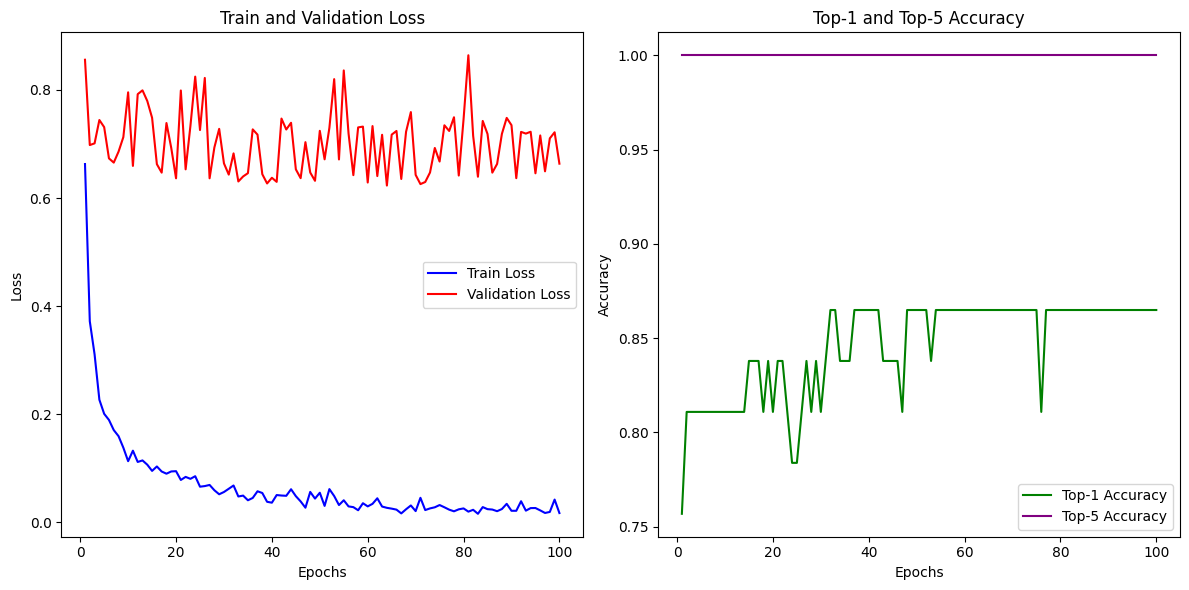

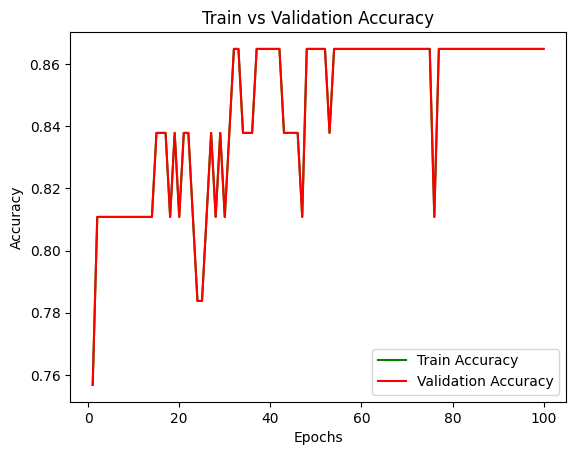

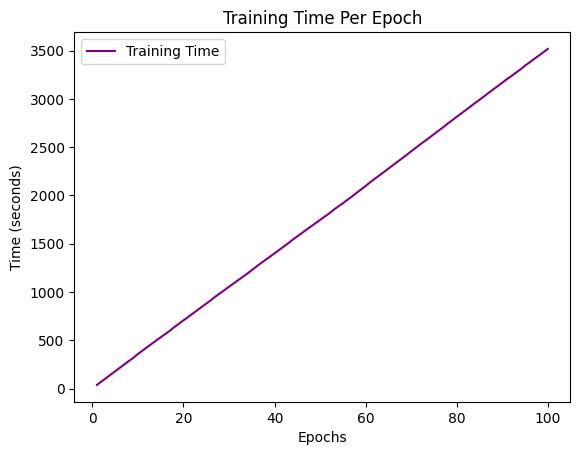

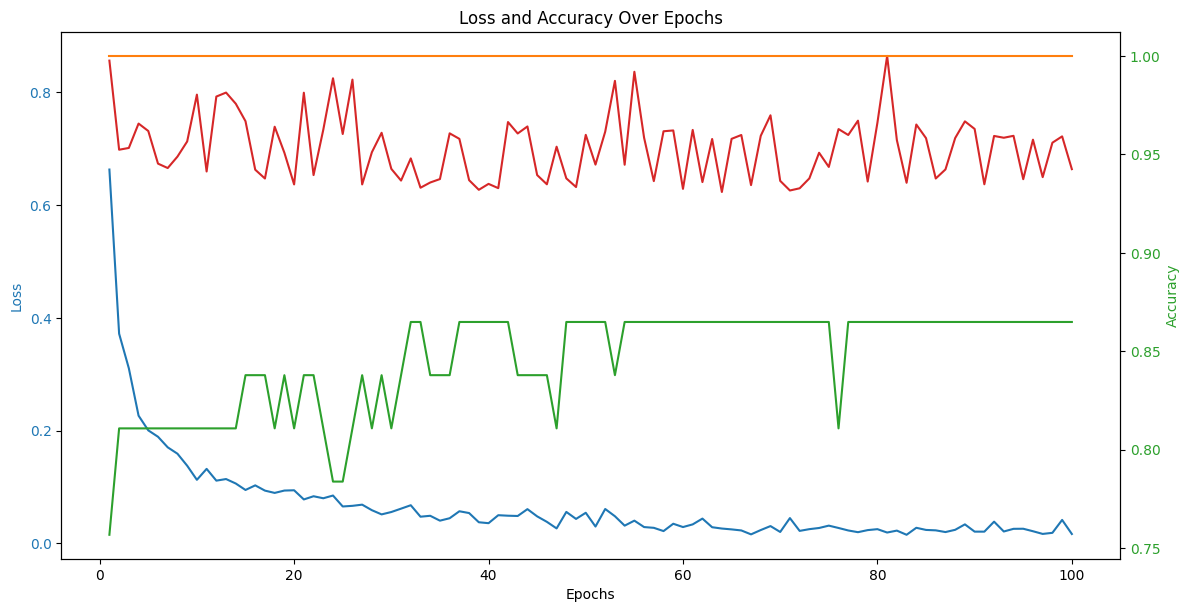

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv('/content/drive/MyDrive/deep fake images 2/sample_data/train/exp/results.csv')

# Extract the relevant columns
epochs = df['epoch']
train_loss = df['train/loss']
val_loss = df['val/loss']
accuracy_top1 = df['metrics/accuracy_top1']
accuracy_top5 = df['metrics/accuracy_top5']

# Plotting Losses
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', color='blue')
plt.plot(epochs, val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy_top1, label='Top-1 Accuracy', color='green')
plt.plot(epochs, accuracy_top5, label='Top-5 Accuracy', color='purple')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Top-1 and Top-5 Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

train_accuracy = df['metrics/accuracy_top1']
val_accuracy = df['metrics/accuracy_top1']  # or replace with validation accuracy column if different

plt.plot(epochs, train_accuracy, label='Train Accuracy', color='green')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, df['time'], label='Training Time', color='purple')
plt.xlabel('Epochs')
plt.ylabel('Time (seconds)')
plt.title('Training Time Per Epoch')
plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='tab:blue')
ax1.plot(epochs, train_loss, label='Train Loss', color='tab:blue')
ax1.plot(epochs, val_loss, label='Validation Loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:green')
ax2.plot(epochs, accuracy_top1, label='Top-1 Accuracy', color='tab:green')
ax2.plot(epochs, accuracy_top5, label='Top-5 Accuracy', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:green')

fig.tight_layout()
plt.title('Loss and Accuracy Over Epochs')
plt.show()



In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/RP/Models/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model.names

{0: 'AI human 2', 1: 'Edited Images', 2: 'Real Human'}

In [ ]:
# import shutil

# # Path to the folder you want to zip
# folder_path = "/content/sample_data/runs"  # Replace with your folder path

# # Output zip file path
# output_zip = "/content/sample_data"

# # Zipping the folder
# shutil.make_archive(output_zip.replace(".zip", ""), 'zip', folder_path)

# print(f"Folder successfully zipped at: {output_zip}")


Folder successfully zipped at: /content/sample_data


In [ ]:
results = model("/content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images/test/AI human 2/6911524a-df7e-4518-9b5a-aa3546dc72fe-1.jpg")


image 1/1 /content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images/test/AI human 2/6911524a-df7e-4518-9b5a-aa3546dc72fe-1.jpg: 640x640 AI human 2 1.00, Edited Images 0.00, Real Human 0.00, 7.8ms
Speed: 91.2ms preprocess, 7.8ms inference, 62.4ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
# Access prediction probabilities
probs = results[0].probs  # Extract probabilities for the first image in the batch
print(probs)
# Get the class with the highest probability
predicted_class_id = probs.top1  # Class ID with the highest probability
confidence = probs.data[predicted_class_id]  # Extract numerical confidence score
label = model.names[predicted_class_id]  # Get the class label

print(f"Predicted Class: {label}, Class ID: {predicted_class_id}, Confidence: {confidence:.2f}")

ultralytics.engine.results.Probs object with attributes:

data: tensor([9.9999e-01, 9.2191e-06, 3.3786e-06], device='cuda:0')
orig_shape: None
shape: torch.Size([3])
top1: 0
top1conf: tensor(1.0000, device='cuda:0')
top5: [0, 1, 2]
top5conf: tensor([9.9999e-01, 9.2191e-06, 3.3786e-06], device='cuda:0')
Predicted Class: AI human 2, Class ID: 0, Confidence: 1.00


In [ ]:
for i, prob in enumerate(probs.data):
    print(f"Class {i} ({model.names[i]}): {prob:.2f}")

Class 0 (AI human 2): 1.00
Class 1 (Edited Images): 0.00
Class 2 (Real Human): 0.00


In [ ]:
import os

# Define the dataset directory paths
train_dir = '/content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images/train'
val_dir = '/content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images/val'

def count_files_in_classes(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

# Count training and validation data
train_counts = count_files_in_classes(train_dir)
val_counts = count_files_in_classes(val_dir)

print("Training Set Class Distribution:", train_counts)
print("Validation Set Class Distribution:", val_counts)


Training Set Class Distribution: {'Edited Images': 254, 'Real Human': 239, 'AI human 2': 256}
Validation Set Class Distribution: {'Edited Images': 25, 'Real Human': 28, 'AI human 2': 30}


In [ ]:
#testing

In [ ]:
from pathlib import Path
from ultralytics import YOLO
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Define the test directory
test_dir = Path("/content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images/test")  # Replace with your test directory path
classes = ["AI human 2", "Edited Images","Real Human"]

# Prepare test images and true labels
test_images = []
true_labels = []

for class_index, class_name in enumerate(classes):
    class_path = test_dir / class_name
    for img_path in class_path.glob("*.jpg"):  # Adjust extension if needed
        test_images.append(str(img_path))
        true_labels.append(class_index)


In [ ]:
# Iterate over the test images
predicted_labels = []

for img_path in test_images:
    results = model(img_path)  # Run inference

    # Access prediction probabilities (assumes probs is available directly)
    probs = results[0].probs  # Extract probabilities for the first image in the batch

    # Get the class with the highest probability
    predicted_class_id = probs.top1  # Class ID with the highest probability
    confidence = probs.data[predicted_class_id]  # Extract numerical confidence score

    # Get the class label from the model names
    label = model.names[predicted_class_id]  # Get the class label

    # Print predicted class, ID, and confidence
    # print(f"Predicted Class: {label}, Class ID: {predicted_class_id}, Confidence: {confidence:.2f}")

    # Append the predicted class id for metrics
    predicted_labels.append(predicted_class_id)



image 1/1 /content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images/test/AI human 2/fd897bfc-e2dd-411a-ba58-10c3aa9a89b1-1.jpg: 640x640 AI human 2 1.00, Edited Images 0.00, Real Human 0.00, 7.8ms
Speed: 17.1ms preprocess, 7.8ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images/test/AI human 2/fc9d9e44-75ff-40c6-8ea0-36e370c05442-1.jpg: 640x640 AI human 2 1.00, Real Human 0.00, Edited Images 0.00, 7.8ms
Speed: 16.5ms preprocess, 7.8ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/RP/DataSets/imageManipulationDetection/imageManipulationDetection/images/test/AI human 2/AI-generated-street-photography-by-RHSumon-63df22f83f10f__700.jpg: 640x640 Real Human 0.99, AI human 2 0.00, Edited Images 0.00, 7.7ms
Speed: 20.8ms preprocess, 7.7ms inference, 0.1ms postprocess per image at shap

In [ ]:
# Calculate metrics
report = classification_report(true_labels, predicted_labels, target_names=classes)
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Print the metrics
print("Classification Report:")
print(report)

print("Confusion Matrix:")
print(conf_matrix)


Classification Report:
               precision    recall  f1-score   support

   AI human 2       1.00      0.93      0.97        15
Edited Images       1.00      0.33      0.50         3
   Real Human       0.67      1.00      0.80         6

     accuracy                           0.88        24
    macro avg       0.89      0.76      0.76        24
 weighted avg       0.92      0.88      0.87        24

Confusion Matrix:
[[14  0  1]
 [ 0  1  2]
 [ 0  0  6]]


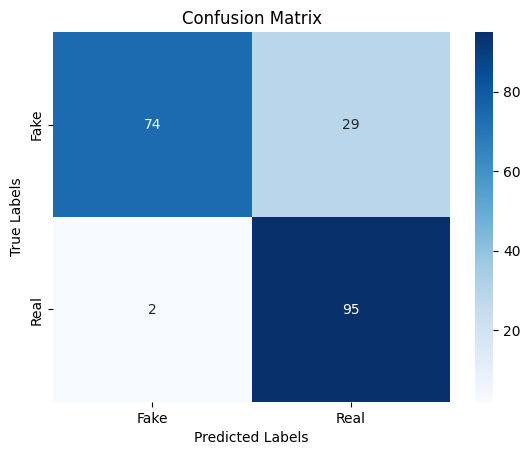

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_matrix, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
